In [1]:
import yfinance as yf

data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

[*********************100%***********************]  1 of 1 completed


In [2]:
data.columns = data.columns.get_level_values(0)

In [3]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [4]:
X = data[["Open","High","Low","Volume"]]
y = data["Close"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
pred = model.predict(X_test)

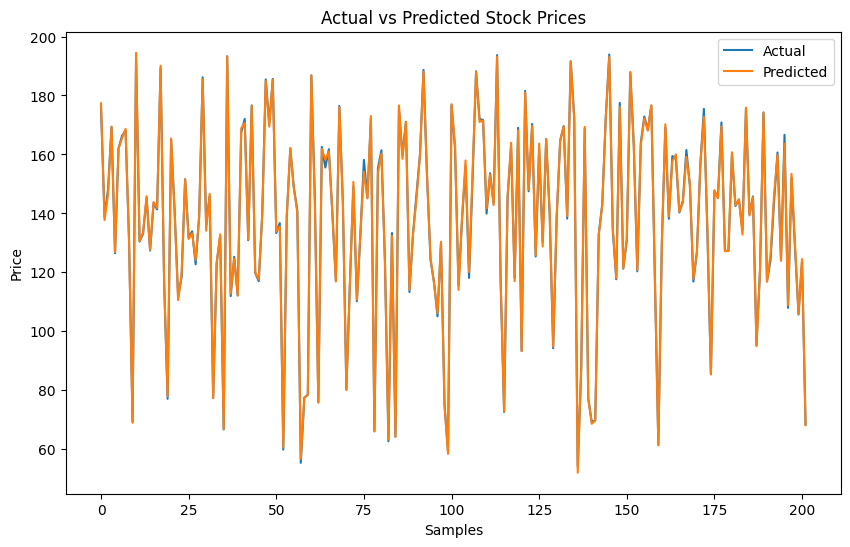

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(y_test.values, label="Actual")
plt.plot(pred, label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Samples")
plt.ylabel("Price")

plt.show()

In [9]:
from sklearn.metrics import mean_absolute_error

print("MAE:", mean_absolute_error(y_test, pred))

MAE: 0.7010241985083843
